**Import Data**

In [1]:
# ================================
# 📦 IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# ================================
# 📂 LOAD DATA
# ================================

# Check files in data folder
print("Files in data folder:", os.listdir("../data"))

# Load dataset
file_path = "../data/new_orleans_airbnb_listings.csv"
df = pd.read_csv(file_path)

# Quick preview
df.head()

Files in data folder: ['new_orleans_airbnb_listings.csv', 'new_orleans_airbnb_reviews.csv']


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,reviews_per_month
0,19091,Fully Furnished Cozy Apartment,CITY OF NEW ORLEANS STR LICENSE PERMIT NUMBER:...,"NorthWest Carrollton, where this apartment is ...",72880,2010-01-23,"New Orleans, Louisiana, United States",within an hour,100%,100%,...,4.89,4.95,4.88,4.97,4.97,4.67,4.91,"17STR-08877, 20-OSTR-0105",t,5.07
1,26834,Maison Mandeville in the Marigny,Ideally-situated Marigny charmer<br /><br /><b...,NaN,114452,2010-04-27,"New Orleans, Louisiana, United States",within a day,100%,81%,...,4.96,4.95,4.97,5.00,4.98,4.93,4.90,"20STR-10811, 20-OSTR-00389",f,2.30
2,71624,Ravenwood Manor (Historic Bywater),You are in for a very unique stay in a neighbo...,"Ours is a neighborhood made up of artists, mus...",367223,2011-01-29,"New Orleans, Louisiana, United States",within an hour,100%,91%,...,4.94,4.91,4.96,4.97,4.98,4.80,4.90,"20RSTR-31027, 20-OSTR-31018",f,2.21
3,74498,Maison Marais 1: Large Local Living,Maison Marais 1 is a stylish one-bedroom apart...,"This is a vibrant, diverse neighborhood of mos...",391462,2011-02-14,"New Orleans, Louisiana, United States",within an hour,100%,95%,...,4.90,4.92,4.96,4.92,4.96,4.64,4.85,"Exempt: This listing is a licensed hotel, mote...",f,8.07
4,79536,FeelAtHomeInNO PrivateApt,Clean & Safe! Spacious private apartment conve...,"I love that it's down to earth, welcoming, his...",428362,2011-03-07,"New Orleans, Louisiana, United States",within an hour,100%,94%,...,4.86,4.92,4.94,4.98,4.97,4.43,4.85,"20RSTR-32056, 20-OSTR-00016",f,5.00


**Data Exploration**

In [2]:
# ================================
# 📊 BASIC DATA UNDERSTANDING
# ================================

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum().sort_values(ascending=False))

Dataset Shape: (6028, 49)

Columns:
 Index(['id', 'name', 'description', 'neighborhood_overview', 'host_id',
       'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_verifications', 'host_has_profile_pic',
       'host_neighbourhood', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'has_availability', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'first_review',
       'last_review', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'r

**Data Cleaning**

In [3]:
# ================================
# 🧹 DATA CLEANING
# ================================

# Convert date columns
date_cols = ["host_since", "first_review", "last_review"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Clean price column
df["price"] = (
    df["price"]
    .replace("[$,]", "", regex=True)
    .astype(float)
)

In [4]:
# Check updated data types
print(df[["host_since", "first_review", "last_review", "price"]].dtypes)

host_since      datetime64[us]
first_review    datetime64[us]
last_review     datetime64[us]
price                  float64
dtype: object


**CREATE WORKING COPY**

In [5]:
# Create working copy
airbnb = df.copy()

**DROP USELESS COLUMNS**

In [6]:
drop_cols = [
    "license",
    "host_neighbourhood",
    "host_location"
]

airbnb.drop(columns=drop_cols, inplace=True)

**HANDLE BEDROOM/BED MISSING VALUES**

In [7]:
airbnb['bedrooms'] = airbnb['bedrooms'].fillna(airbnb['bedrooms'].median())
airbnb['beds'] = airbnb['beds'].fillna(airbnb['beds'].median())

**HANDLE DESCRIPTION TEXT**

In [8]:
airbnb['description'] = airbnb['description'].fillna(" ")
airbnb['neighborhood_overview'] = airbnb['neighborhood_overview'].fillna(" ")

**HANDLE REVIEW SCORES**

In [9]:
review_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

for col in review_cols:
    airbnb[col] = airbnb[col].fillna(
        airbnb[col].median()
    )

**HANDLE HOST FEATURES**

In [10]:
airbnb['host_response_rate'] = airbnb['host_response_rate'].fillna("0%")
airbnb['host_acceptance_rate'] = airbnb['host_acceptance_rate'].fillna("0%")
airbnb['host_response_time'] = airbnb['host_response_time'].fillna("unknown")

**CHECK FOR NULL VALUES**

In [11]:
# Remaining missing values
print(
    airbnb.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

reviews_per_month         672
first_review              672
last_review               672
host_listings_count        38
host_since                 38
host_identity_verified     38
host_has_profile_pic       38
host_verifications         38
host_is_superhost          38
bathrooms_text             16
host_id                     0
neighborhood_overview       0
description                 0
name                        0
host_response_rate          0
host_response_time          0
host_acceptance_rate        0
id                          0
property_type               0
neighbourhood_cleansed      0
dtype: int64


**FILL REMAINING NULL VALUES**

In [12]:
airbnb["reviews_per_month"] = airbnb["reviews_per_month"].fillna(0)


In [13]:
bool_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified"
]

for col in bool_cols:
    airbnb[col] = airbnb[col].fillna("f")

In [14]:
airbnb["host_verifications"] = airbnb["host_verifications"].fillna("[]")


In [15]:
airbnb["host_since"] = airbnb["host_since"].fillna(airbnb["host_since"].mode()[0])


In [16]:
airbnb["host_listings_count"] = airbnb["host_listings_count"].fillna(airbnb["host_listings_count"].median())


In [17]:
airbnb["bathrooms_text"] = airbnb["bathrooms_text"].fillna("1 bath")


In [18]:
# Remaining missing values
print(
    airbnb.isnull().sum()
    .sort_values(ascending=False)
    .head(5)
)

last_review              672
first_review             672
description                0
neighborhood_overview      0
id                         0
dtype: int64


In [19]:
airbnb.shape

(6028, 46)

**EXPLORATORY DATA ANALYSIS (EDA)**

**1) Price Distribution**

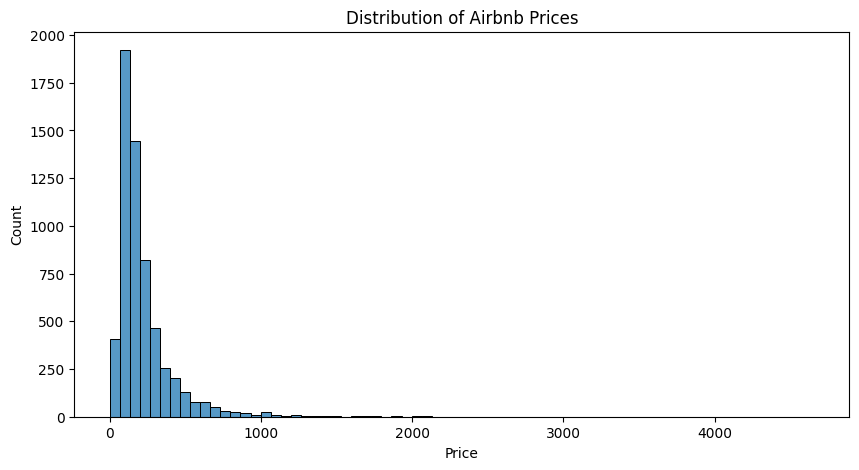

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(airbnb["price"], bins=70)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [21]:

valid = airbnb.dropna(subset=["price"])

pct = valid["price"].between(0, 1000).mean() * 100
print(f"{pct:.2f}% of listings have price between $0 and $1000")


98.72% of listings have price between $0 and $1000


* More than 98% of AirBNBs prices are between 0-1000$ 

**2) Top Property Types**

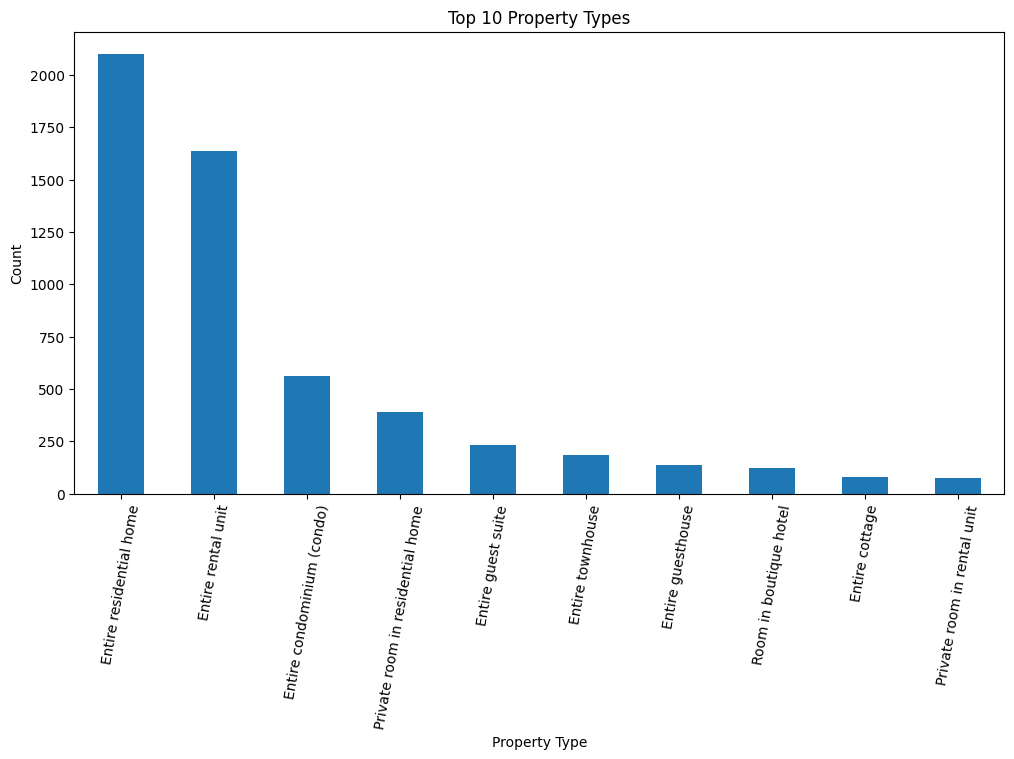

In [22]:
plt.figure(figsize=(12,6))

airbnb["property_type"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Property Types")
plt.xlabel("Property Type")
plt.ylabel("Count")

plt.xticks(rotation=80)

plt.show()

* Most common type of property type is - Entire Residential home, with more than 2000+ listings

**3) Room Type Distribution**

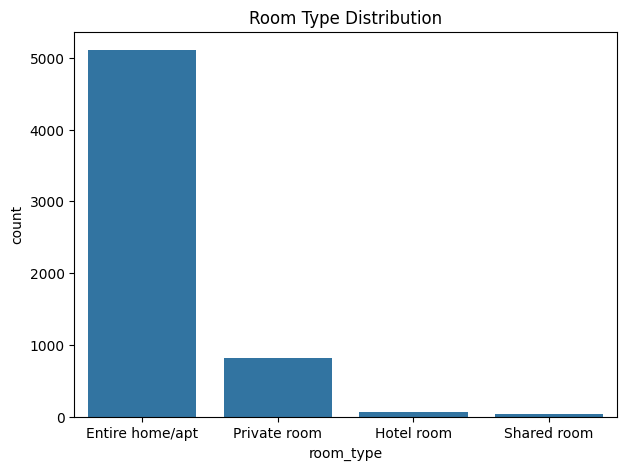

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(data=airbnb, x="room_type")

plt.title("Room Type Distribution")

plt.show()

* Entire home or apartment is the most dominant kind of room type distribution.

**4) Ratings Distribution**

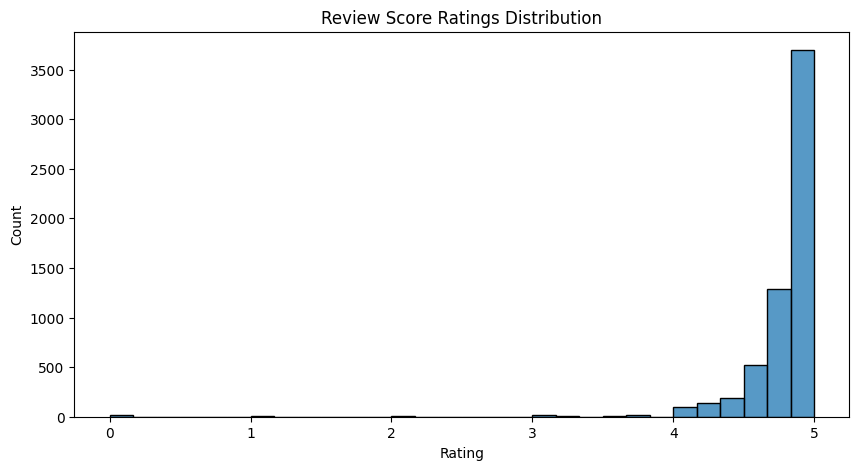

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    airbnb["review_scores_rating"],
    bins=30
)

plt.title("Review Score Ratings Distribution")

plt.xlabel("Rating")

plt.show()

In [25]:
scores = airbnb["review_scores_rating"]
pct = scores.between(4, 5).mean() * 100

print(f"{pct:.2f}% of listings have review scores between 4 and 5")

98.54% of listings have review scores between 4 and 5


* 98.54% of listings have review scores between 4 and 5

**5) Most Common Neighborhoods**

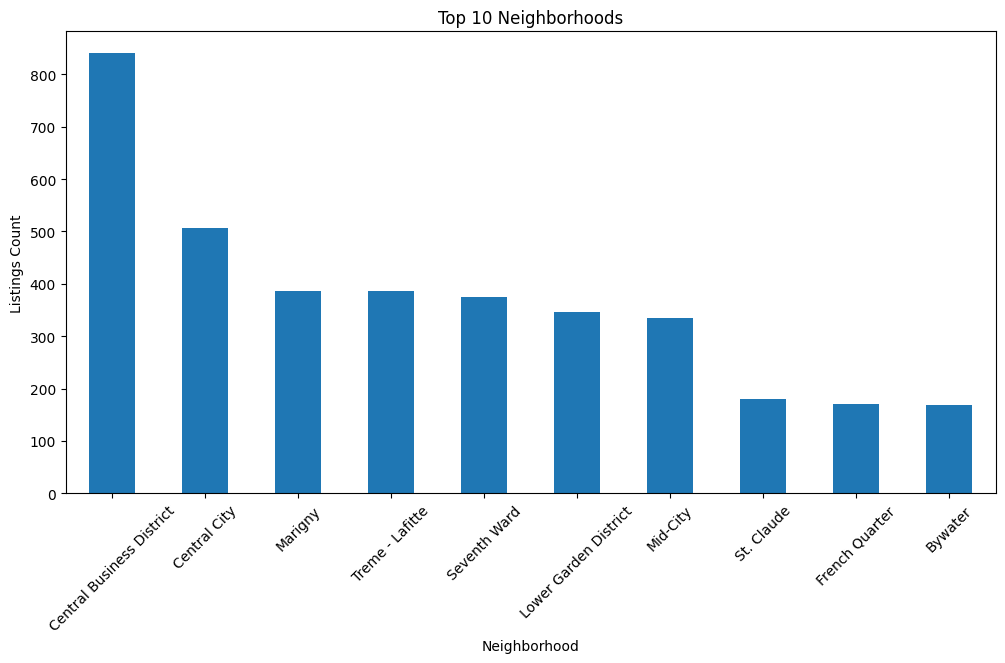

In [26]:
top_neighborhoods = (
    airbnb["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_neighborhoods.plot(kind="bar")

plt.title("Top 10 Neighborhoods")

plt.xlabel("Neighborhood")
plt.ylabel("Listings Count")

plt.xticks(rotation=45)

plt.show()

* Most common neighborhood is - Central Business District. 

**6) Price vs Ratings**

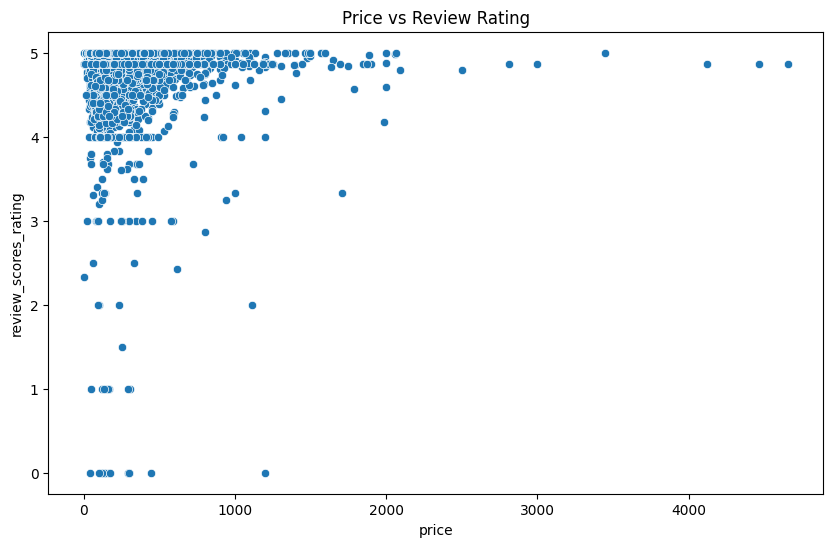

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=airbnb,
    x="price",
    y="review_scores_rating"
)

plt.title("Price vs Review Rating")

plt.show()

In [28]:
max_price = airbnb["price"].max()
print(f"Maximum price: ${max_price:.2f}")

Maximum price: $4657.00


In [29]:
min_price = airbnb["price"].min()
print(f"Minimum price: ${min_price:.2f}")

Minimum price: $0.00


In [30]:
airbnb = airbnb[airbnb["price"] > 0]

In [31]:
min_price = airbnb["price"].min()
print(f"Minimum price: ${min_price:.2f}")

Minimum price: $11.00


**7) Accommodates vs Price**

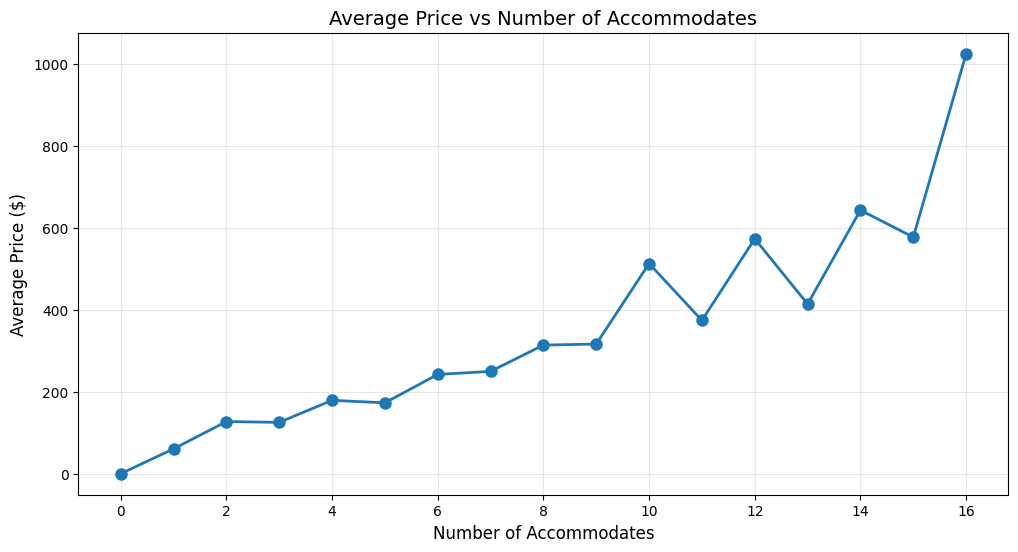

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by accommodates and calculate mean price
accommodates_price = df.groupby("accommodates")["price"].mean().reset_index()

# Create line plot
plt.figure(figsize=(12, 6))
plt.plot(accommodates_price["accommodates"], accommodates_price["price"], marker="o", linewidth=2, markersize=8)
plt.xlabel("Number of Accommodates", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Average Price vs Number of Accommodates", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

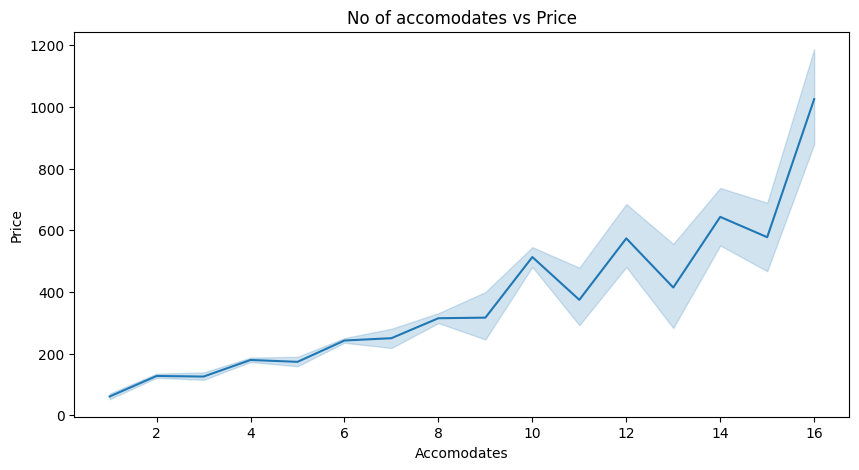

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(data = airbnb, x="accommodates", y="price")
plt.title("No of accomodates vs Price")
plt.xlabel("Accomodates")
plt.ylabel("Price")
plt.show()

**Data Cleaning - Amenities**

In [34]:
airbnb["amenities"].iloc[0]

'["TV with standard cable", "Hair dryer", "Air conditioning", "Refrigerator", "Essentials", "Microwave", "Coffee maker", "Fire extinguisher", "Single level home", "Cooking basics", "Private entrance", "Hangers", "Shampoo", "Patio or balcony", "Bed linens", "Kitchen", "Carbon monoxide alarm", "Paid parking on premises", "Hot water", "Smoke alarm", "Stove", "Shower gel", "Long term stays allowed", "Backyard", "Iron", "Extra pillows and blankets", "Heating", "Dishes and silverware", "Free street parking", "Keypad", "Luggage dropoff allowed", "Wifi", "Oven", "Cable TV"]'

In [35]:
import ast

# Convert amenities string to actual Python list
airbnb["amenities"] = airbnb["amenities"].apply(ast.literal_eval)

In [36]:
type(airbnb["amenities"].iloc[0])

list

**Amenities count**

In [37]:
from collections import Counter

# Flatten all amenities into one list
all_amenities = []

for amenities_list in airbnb["amenities"]:
    all_amenities.extend(amenities_list)

# Count frequencies
amenity_counts = Counter(all_amenities)

# Top 20 amenities
top_amenities = pd.DataFrame(
    amenity_counts.most_common(20),
    columns=["Amenity", "Count"]
)

top_amenities

,Amenity,Count
0,Wifi,5871
1,Smoke alarm,5840
2,Air conditioning,5722
3,Essentials,5712
4,Heating,5603
5,Iron,5474
6,Hangers,5404
7,Hair dryer,5392
8,Long term stays allowed,5286
9,Fire extinguisher,5257


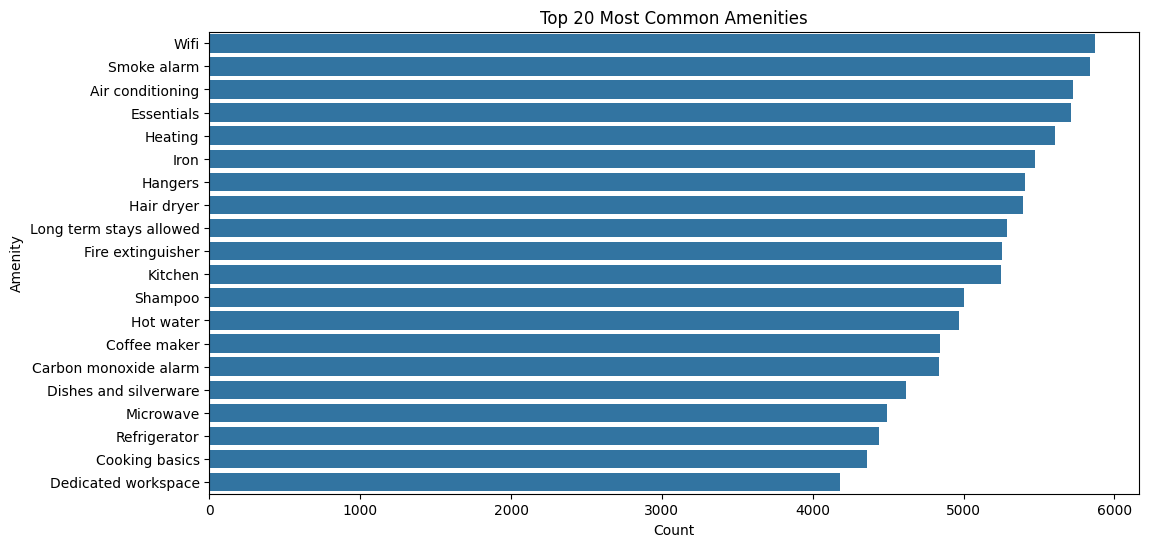

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_amenities,
    x="Count",
    y="Amenity"
)

plt.title("Top 20 Most Common Amenities")

plt.show()

# **Basic TF-IDF Vectorization**

**BUILD RECOMMENDATION FEATURES**

In [39]:
# Combine important text features
airbnb["combined_features"] = (
    airbnb["name"].fillna('') + " " +
    airbnb["description"].fillna('') + " " +
    airbnb["property_type"].fillna('') + " " +
    airbnb["room_type"].fillna('') + " " +
    airbnb["neighbourhood_cleansed"].fillna('')
)

In [40]:
airbnb["amenities_text"] = airbnb["amenities"].apply(
    lambda x: " ".join(x)
)

In [41]:
airbnb["combined_features"] = (
    airbnb["combined_features"] + " " +
    airbnb["amenities_text"]
)

In [42]:
print(airbnb['combined_features'].head(5))

0    Fully Furnished Cozy Apartment CITY OF NEW ORL...
1    Maison Mandeville in the Marigny Ideally-situa...
2    Ravenwood Manor (Historic Bywater) You are in ...
3    Maison Marais 1: Large Local Living Maison Mar...
4    FeelAtHomeInNO PrivateApt Clean & Safe! Spacio...
Name: combined_features, dtype: str


**Import TF-IDF**

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

**Create TF-IDF Vectorizer**

In [44]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

**Transform Combined Features**

In [45]:
tfidf_matrix = tfidf.fit_transform(
    airbnb["combined_features"]
)

In [46]:
airbnb.shape

(6019, 48)

In [47]:
tfidf_matrix.shape

(6019, 5000)

**Compute Similarity**

In [48]:
cosine_sim = cosine_similarity(tfidf_matrix)

**CREATE INDEX MAPPING**

In [49]:
# Create index mapping
indices = pd.Series(
    airbnb.index,
    index=airbnb["name"]
).drop_duplicates()

**BUILD RECOMMENDATION FUNCTION**

In [50]:
def recommend_airbnb(listing_name, top_n=5):

    # Get index of selected listing
    idx = indices[listing_name]

    # Get similarity scores
    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort by similarity score
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    sim_scores = sim_scores[1:top_n+1]

    # Get recommended indices
    listing_indices = [
        i[0] for i in sim_scores
    ]

    # Return important columns
    return airbnb[
        [
            "name",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating"
        ]
    ].iloc[listing_indices]

In [51]:
airbnb["name"].iloc[0]

'Fully Furnished Cozy Apartment'

In [52]:
recommend_airbnb("Fully Furnished Cozy Apartment")

,name,property_type,room_type,price,review_scores_rating
485,Charming Garden District Apartment,Entire rental unit,Entire home/apt,189.0,4.84
1709,Uptown New Orleans Apartment,Entire guest suite,Entire home/apt,75.0,4.97
2268,Private cozy New Orleans apartment.,Entire rental unit,Entire home/apt,65.0,4.94
1261,Huge Property in Great Location 2116,Entire residential home,Entire home/apt,177.0,4.93
1274,Huge Mardi Gras Parade Home 2120,Entire residential home,Entire home/apt,235.0,4.86


**TF-IDF vectorization convert the text into vectors based on words frequencies, it doesn't understand the conceptual meaning of words it is encoding. Hence it misses synonyms and similar based words. To avoid this, we introduce encoders. Which understands the text for it's meaning, and can match same meaning, and similar context words.**

# **Sentence Transformers**

**Install sentence-transformers library**

In [53]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Import Encoder**

In [54]:
from sentence_transformers import SentenceTransformer

**Sentence transformers are built using Transformer Encoder Networks (like BERT)**
**And they were pretrained on MASSIVE text datasets from the internet to understand the meaning and context of the several sentences**

**Load Model**

In [55]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

**Generate Embeddings**

In [56]:
embeddings = model.encode(
    airbnb["combined_features"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

In [57]:
embeddings.shape

(6019, 384)

**Embedding dimension depends on model architecture - it is automatically created by the chosen model**

In [58]:
embeddings[3]

array([ 4.46543992e-02,  1.48150744e-02,  3.64551879e-02,  4.27236259e-02,
       -2.10126061e-02,  2.03816723e-02, -1.00267891e-04, -8.49507451e-02,
       -2.43460350e-02, -2.59462893e-02, -4.04211432e-02,  3.65722962e-02,
        4.48729061e-02, -8.57490227e-02,  1.66009255e-02, -7.26192668e-02,
        6.86342493e-02, -4.22821790e-02,  4.63460498e-02,  5.76912053e-02,
        5.85397566e-03, -4.71370034e-02,  5.04214354e-02,  5.11132888e-02,
       -2.91434079e-02, -1.49070295e-02, -7.95739293e-02,  8.76783431e-02,
        4.26645949e-03, -2.76147369e-02,  7.67888501e-02,  1.15679741e-01,
        2.18601674e-02,  2.28932104e-03,  4.06042151e-02,  5.71234189e-02,
        8.06059316e-02, -1.59841496e-02,  2.66583562e-02,  4.60607968e-02,
       -7.05331471e-03, -1.48616126e-02,  5.14715491e-03, -1.71652492e-02,
       -9.80755165e-02, -5.55007868e-02, -3.13905962e-02, -1.13209626e-02,
        1.27304876e-02, -8.59450027e-02, -3.45657542e-02,  8.17925632e-02,
       -5.26291654e-02,  

**Semantic Similarity Matrix**

In [59]:
semantic_similarity = cosine_similarity(embeddings)

**BUILD RECOMMENDATION FUNCTION**

In [60]:
def semantic_recommend_airbnb(listing_name, top_n=5):

    # Get index of selected listing
    idx = indices[listing_name]

    # Get similarity scores
    semantic_sim_scores = list(
        enumerate(semantic_similarity[idx])
    )

    # Sort by similarity score
    semantic_sim_scores = sorted(
        semantic_sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    semantic_sim_scores = semantic_sim_scores[1:top_n+1]

    # Get recommended indices
    listing_indices = [
        i[0] for i in semantic_sim_scores
    ]

    # Return important columns
    return airbnb[
        [
            "name",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating"
        ]
    ].iloc[listing_indices]

In [61]:
airbnb["name"].iloc[0]

'Fully Furnished Cozy Apartment'

In [62]:
semantic_recommend_airbnb("Fully Furnished Cozy Apartment")

,name,property_type,room_type,price,review_scores_rating
917,Mid City 4 BR Close to Canal Street,Entire residential home,Entire home/apt,389.0,4.70
4987,"~ The Catherine ~ SPACIOUS, FRONT FACING APART...",Entire rental unit,Entire home/apt,754.0,4.86
2798,Full house 2blks from Jazz Fest in New Orleans!,Entire residential home,Entire home/apt,1350.0,5.00
3875,🌳The Cypress🌳 Corner Apt with Outdoor Space!!,Entire rental unit,Entire home/apt,325.0,5.00
3877,"~ The Natchez ~ Location, Location, Location",Entire rental unit,Entire home/apt,335.0,4.86


# **Sentence Transfomers - with Reviews included**

**Load Reviews Dataset**

In [63]:
# Load dataset
reviews = "../data/new_orleans_airbnb_reviews.csv"
df_reviews = pd.read_csv(reviews)

# Quick preview
df_reviews.head()

,listing_id,id,date,reviewer_id,comments
0,19091,35930,2010-04-16,97343,John was extremely accommodating to our schedu...
1,19091,45900,2010-05-24,99114,John was a great host and made sure that I cou...
2,19091,61668,2010-07-06,128406,My husband and I stayed with John last month a...
3,19091,96538,2010-09-13,228880,John is a great host for your time in New Orle...
4,19091,108793,2010-09-30,214223,john is a fantastic host. the place is perfe...


In [64]:
df_reviews.sample(5)

,listing_id,id,date,reviewer_id,comments
112341,12777156,131919646,2017-02-14,73576620,Me and my fiancé had an amazing time staying i...
225315,23379514,511658584,2019-08-17,103698110,Great hosts and very clean.
145579,16189237,584724935,2019-12-30,221333626,Great location - easy walk or ride share to ac...
227665,23596574,567465365,2019-11-22,93939525,Great location to explore New Orleans from. Pa...
247561,25888544,497618120,2019-07-28,103605307,"We had a great stay! The check-in was easy, sp..."


In [65]:
airbnb.head()

,id,name,description,neighborhood_overview,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,reviews_per_month,combined_features,amenities_text
0,19091,Fully Furnished Cozy Apartment,CITY OF NEW ORLEANS STR LICENSE PERMIT NUMBER:...,"NorthWest Carrollton, where this apartment is ...",72880,2010-01-23,within an hour,100%,100%,t,...,4.95,4.88,4.97,4.97,4.67,4.91,t,5.07,Fully Furnished Cozy Apartment CITY OF NEW ORL...,TV with standard cable Hair dryer Air conditio...
1,26834,Maison Mandeville in the Marigny,Ideally-situated Marigny charmer<br /><br /><b...,,114452,2010-04-27,within a day,100%,81%,t,...,4.95,4.97,5.00,4.98,4.93,4.90,f,2.30,Maison Mandeville in the Marigny Ideally-situa...,Air conditioning Refrigerator Essentials Hot w...
2,71624,Ravenwood Manor (Historic Bywater),You are in for a very unique stay in a neighbo...,"Ours is a neighborhood made up of artists, mus...",367223,2011-01-29,within an hour,100%,91%,t,...,4.91,4.96,4.97,4.98,4.80,4.90,f,2.21,Ravenwood Manor (Historic Bywater) You are in ...,TV with standard cable Hair dryer Air conditio...
3,74498,Maison Marais 1: Large Local Living,Maison Marais 1 is a stylish one-bedroom apart...,"This is a vibrant, diverse neighborhood of mos...",391462,2011-02-14,within an hour,100%,95%,t,...,4.92,4.96,4.92,4.96,4.64,4.85,f,8.07,Maison Marais 1: Large Local Living Maison Mar...,Air conditioning Refrigerator Essentials Micro...
4,79536,FeelAtHomeInNO PrivateApt,Clean & Safe! Spacious private apartment conve...,"I love that it's down to earth, welcoming, his...",428362,2011-03-07,within an hour,100%,94%,t,...,4.92,4.94,4.98,4.97,4.43,4.85,f,5.00,FeelAtHomeInNO PrivateApt Clean & Safe! Spacio...,Air conditioning Refrigerator Essentials Micro...


In [66]:
df_reviews["comments"] = df_reviews["comments"].fillna(" ")

**Group user comments of each property into one text column**

In [67]:
# Aggregate all reviews per listing_id
reviews_grouped = df_reviews.groupby("listing_id")["comments"].apply(
    lambda x: " ".join(x.astype(str))
).reset_index()

# Rename column
reviews_grouped.rename(
    columns={"comments": "user_comments"},
    inplace=True
)

# limit review text length
reviews_grouped["user_comments"] = (
    reviews_grouped["user_comments"].str[:5000]
)

In [68]:
df_reviews.head()

,listing_id,id,date,reviewer_id,comments
0,19091,35930,2010-04-16,97343,John was extremely accommodating to our schedu...
1,19091,45900,2010-05-24,99114,John was a great host and made sure that I cou...
2,19091,61668,2010-07-06,128406,My husband and I stayed with John last month a...
3,19091,96538,2010-09-13,228880,John is a great host for your time in New Orle...
4,19091,108793,2010-09-30,214223,john is a fantastic host. the place is perfe...


**Merge listings and reviews datasets**

In [69]:
airbnb_merged = pd.merge(airbnb, reviews_grouped, left_on="id", right_on="listing_id", how="left")

In [70]:
# Check shape
print(airbnb_merged.shape)

(6019, 50)


**BUILD RECOMMENDATION FEATURES**

In [71]:
# ================================
# 🧠 CREATE COMBINED FEATURES
# ================================

airbnb_merged["combined_features"] = (
    airbnb_merged["name"].fillna('') + " " +
    airbnb_merged["description"].fillna('') + " " +
    airbnb_merged["property_type"].fillna('') + " " +
    airbnb_merged["room_type"].fillna('') + " " +
    airbnb_merged["neighbourhood_cleansed"].fillna('') + " " +
    airbnb_merged["amenities_text"].fillna('') + " " +
    airbnb_merged["user_comments"].fillna('')
)

In [72]:
# Preview one combined feature row
print(airbnb_merged["combined_features"].iloc[0][:1000])

Fully Furnished Cozy Apartment CITY OF NEW ORLEANS STR LICENSE PERMIT NUMBER:  17STR--08877<br />CITY OF NEW ORLEANS STR OPERATOR LICENSE NUMBER:  20-00105-0STR<br /><br />This cozy space is a wonder of post-Katrina recovery detailing.  Finely finished doors, cabinets, and wood molding are made from Katrina debris.  The hand-painted floors are a marvel of trompe-l'œil ingenuity.  SPECIAL  SUMMER PRICING!<br /><br /><b>The space</b><br />SEE SPECIAL REDUCED SUMMER PRICING!  <br /><br />This apartment is ideal for two people, but can accommodate four if two do not mind using an Aerobed in the living room area.  <br /><br />The City of New Orleans requires that  all Airbnb Hosts be licensed and issued a permit. The License Permit number for this listing is 17STR-08877.<br /><br />Located in Northwest Carrollton, this apartment is 10 minutes from the French Quarter by car, 8 blocks from the streetcar line, 4 blocks from the bus, and 4 blocks from the world famous Rock 'n Bowl bar/bowling l

**GENERATE EMBEDDINGS**

In [ ]:
review_embeddings = model.encode(
    airbnb_merged["combined_features"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

**COMPUTE COSINE SIMILARITY**

In [ ]:
semantic_review_similarity = cosine_similarity(review_embeddings)

**CREATE INDEX MAPPING**

In [ ]:
merged_indices = pd.Series(
    airbnb_merged.index,
    index=airbnb_merged["name"]
).drop_duplicates()

**RECOMMENDATION FUNCTION**

In [ ]:
def semantic_review_recommend_airbnb(listing_name, top_n=5):

    # Get index of selected listing
    idx = merged_indices[listing_name]

    # Get similarity scores
    semantic_review_sim_scores = list(
        enumerate(semantic_review_similarity[idx])
    )

    # Sort by similarity score
    semantic_review_sim_scores = sorted(
        semantic_review_sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    semantic_review_sim_scores = semantic_review_sim_scores[1:top_n+1]

    # Get recommended indices
    listing_indices = [
        i[0] for i in semantic_review_sim_scores
    ]

    # Return important columns
    return airbnb_merged[
        [
            "name",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating"
        ]
    ].iloc[listing_indices]

# **Testing 3 reommendation functions**

In [ ]:
airbnb_merged["name"].iloc[15]

'2 Bed, 2.5 Bath Comfort near French Quarter'

In [ ]:
semantic_review_recommend_airbnb("2 Bed, 2.5 Bath Comfort near French Quarter")

,name,property_type,room_type,price,review_scores_rating
2018,Holidays Like a local near the French Quarter,Entire residential home,Entire home/apt,239.0,4.63
3935,BREATHTAKING! 5 Bedroom home near *FRENCH QUAR...,Entire townhouse,Entire home/apt,317.0,4.64
4852,Spacious Gated Apartment w/ Off Street Parking!,Entire rental unit,Entire home/apt,169.0,4.63
3858,Gorgeous 5 bedroom Home Near **FRENCH QUARTER**,Entire residential home,Entire home/apt,386.0,4.74
3968,MODERN 5 Bedroom Near FRENCH QUARTER!,Entire townhouse,Entire home/apt,338.0,4.49


In [ ]:
semantic_recommend_airbnb("2 Bed, 2.5 Bath Comfort near French Quarter")

,name,property_type,room_type,price,review_scores_rating
2018,Holidays Like a local near the French Quarter,Entire residential home,Entire home/apt,239.0,4.63
3935,BREATHTAKING! 5 Bedroom home near *FRENCH QUAR...,Entire townhouse,Entire home/apt,317.0,4.64
4860,Spacious Gated Apartment w/ Off Street Parking!,Entire rental unit,Entire home/apt,169.0,4.63
3858,Gorgeous 5 bedroom Home Near **FRENCH QUARTER**,Entire residential home,Entire home/apt,386.0,4.74
3968,MODERN 5 Bedroom Near FRENCH QUARTER!,Entire townhouse,Entire home/apt,338.0,4.49


In [ ]:
recommend_airbnb("2 Bed, 2.5 Bath Comfort near French Quarter")

,name,property_type,room_type,price,review_scores_rating
213,Charles Suite - 2 bed 2.5 bath near French Qua...,Entire townhouse,Entire home/apt,225.0,4.58
16,Muse Suite- Near French Quarter,Entire townhouse,Entire home/apt,210.0,4.84
761,Charming Home in Lovely Gentilly,Entire residential home,Entire home/apt,250.0,4.74
3736,1 Bedroom Gem - 4 blocks to French Quarter,Entire rental unit,Entire home/apt,150.0,4.80
4531,Treme Suite: Stylish 1BD/1BA+Free Parking,Entire guest suite,Entire home/apt,116.0,4.75


# **Recommendation function with input as user query**

**Till now the system worked through taking input as the name of the property in the listings, but that is not how real world recommendation systems works. To make it more real-world applicable, we need to compare the given user query with the available listings.**

**RECOMMENDATION FUNCTION**

In [ ]:
def semantic_search_airbnb(user_query, top_n=5):

    # Encode user query
    query_embedding = model.encode([user_query])

    # Compute similarity with all listings
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )

    # Get similarity scores
    sim_scores = list(
        enumerate(similarities[0])
    )

    # Sort descending
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Top matches
    top_matches = sim_scores[:top_n]

    # Extract indices
    listing_indices = [
        i[0] for i in top_matches
    ]

    # Return results
    return airbnb_merged[
        [
            "name",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating"
        ]
    ].iloc[listing_indices]

In [ ]:
semantic_search_airbnb(
    "quiet romantic apartment near nightlife"
)

,name,property_type,room_type,price,review_scores_rating
3706,Romantic Nola Getaway,Entire rental unit,Entire home/apt,99.0,4.86
1774,Awesome One Bedroom Steps Away from French Qua...,Entire rental unit,Entire home/apt,189.0,4.90
890,Cozy Downstairs apt in Musician's Village,Entire rental unit,Entire home/apt,77.0,4.85
455,Cozy Private Rooms in Amazing Polka Dot House,Private room in residential home,Private room,50.0,4.81
4162,Cozy and Private Master BedRoom,Private room in residential home,Private room,100.0,5.00


In [ ]:
semantic_search_airbnb(
    "family-friendly home with parking"
)

,name,property_type,room_type,price,review_scores_rating
2239,Kid Friendly Home in New Orleans,Entire guest suite,Entire home/apt,89.0,4.88
1022,3 Bedroom House in Treme with Off Street Parking,Entire residential home,Entire home/apt,325.0,4.99
4011,Beautiful & Spacious NOLA Close to Fairgrounds,Entire residential home,Entire home/apt,142.0,4.26
313,Adorable 2br Uptown Cottage,Entire residential home,Entire home/apt,94.0,4.89
567,PrivHome/2.3mi to FrenchQuarter/0.4 mi to City...,Entire residential home,Entire home/apt,131.0,4.97


In [ ]:
semantic_search_airbnb(
    "workspace with fast wifi for remote work"
)

,name,property_type,room_type,price,review_scores_rating
4711,"Colorful duplex with free WiFi, central AC, re...",Entire residential home,Entire home/apt,291.0,4.67
3995,Guest house on Frenchmen Street,Entire residential home,Entire home/apt,120.0,4.90
560,"Sunny Spot - parking , 15 minutes drive to Fr....",Entire rental unit,Entire home/apt,114.0,4.92
3988,The Big Easy,Entire townhouse,Entire home/apt,225.0,4.50
1757,Private room for rent 5 Minutes from Downtown ...,Private room in townhouse,Private room,45.0,4.53


# **Filtering System + Generate Explanations**

In [ ]:
# =========================================================
# 🚀 GENERATE EMBEDDINGS
# =========================================================

embeddings = model.encode(
    airbnb_merged["combined_features"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

In [ ]:
# =========================================================
# 🧠 HYBRID SEMANTIC AIRBNB RECOMMENDATION SYSTEM
# =========================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# =========================================================
# 🚀 HYBRID SEARCH FUNCTION
# =========================================================

def hybrid_airbnb_search(
    query,
    max_price=None,
    room_type=None,
    min_rating=None,
    accommodates=None,
    top_n=5
):

    # =====================================================
    # 📌 STEP 1 — COPY DATAFRAME
    # =====================================================

    filtered_df = airbnb_merged.copy()

    # =====================================================
    # 📌 STEP 2 — APPLY FILTERS
    # =====================================================

    # Filter by maximum price
    if max_price is not None:
        filtered_df = filtered_df[
            filtered_df["price"] <= max_price
        ]

    # Filter by room type
    if room_type is not None:
        filtered_df = filtered_df[
            filtered_df["room_type"] == room_type
        ]

    # Filter by minimum rating
    if min_rating is not None:
        filtered_df = filtered_df[
            filtered_df["review_scores_rating"] >= min_rating
        ]

    # Filter by accommodates
    if accommodates is not None:
        filtered_df = filtered_df[
            filtered_df["accommodates"] >= accommodates
        ]

    # =====================================================
    # 📌 STEP 3 — HANDLE EMPTY RESULTS
    # =====================================================

    if filtered_df.empty:
        return "No matching Airbnb listings found."

    # =====================================================
    # 📌 STEP 4 — ENCODE USER QUERY
    # =====================================================

    query_embedding = model.encode([query])

    filtered_embeddings = embeddings[filtered_df.index]

    # =====================================================
    # 📌 STEP 5 — COMPUTE COSINE SIMILARITY
    # =====================================================

    similarities = cosine_similarity(
        query_embedding,
        filtered_embeddings
    )

    # =====================================================
    # 📌 STEP 6 — GET TOP MATCHES
    # =====================================================

    sim_scores = list(
        enumerate(similarities[0])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_matches = sim_scores[:top_n]

    # =====================================================
    # 📌 STEP 7 — EXTRACT INDICES
    # =====================================================

    listing_indices = [
        i[0] for i in top_matches
    ]

    # =====================================================
    # 📌 STEP 8 — CREATE RESULT DATAFRAME
    # =====================================================

    recommendations = filtered_df.iloc[
        listing_indices
    ][
        [
            "name",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating",
            "accommodates"
        ]
    ].copy()

    # =====================================================
    # 📌 STEP 9 — ADD SIMILARITY SCORE
    # =====================================================

    recommendations["similarity_score"] = [
        round(i[1], 3) for i in top_matches
    ]

    # =====================================================
    # 📌 STEP 10 — GENERATE EXPLANATIONS
    # =====================================================

    explanations = []

    for _, row in recommendations.iterrows():

        explanation = []

        # Rating explanation
        if row["review_scores_rating"] >= 4.8:
            explanation.append(
                "Highly rated by guests"
            )

        # Budget explanation
        if max_price and row["price"] <= max_price:
            explanation.append(
                "Matches your budget"
            )

        # Room type explanation
        if room_type:
            explanation.append(
                f"{room_type} stay"
            )

        # Accommodates explanation
        if accommodates:
            explanation.append(
                f"Suitable for {accommodates}+ guests"
            )

        explanations.append(
            " • ".join(explanation)
        )

    recommendations["why_recommended"] = explanations

    # =====================================================
    # 📌 STEP 11 — RETURN RESULTS
    # =====================================================

    return recommendations



**TEST EXAMPLES**

In [ ]:
hybrid_airbnb_search(
    query="quiet romantic apartment near nightlife",
    max_price=200,
    room_type="Entire home/apt",
    min_rating=4.5,
    accommodates=2,
    top_n=5
)

,name,property_type,room_type,price,review_scores_rating,accommodates,similarity_score,why_recommended
3706,Romantic Nola Getaway,Entire rental unit,Entire home/apt,99.0,4.86,3,0.663,Highly rated by guests • Matches your budget •...
1774,Awesome One Bedroom Steps Away from French Qua...,Entire rental unit,Entire home/apt,189.0,4.90,6,0.655,Highly rated by guests • Matches your budget •...
890,Cozy Downstairs apt in Musician's Village,Entire rental unit,Entire home/apt,77.0,4.85,4,0.647,Highly rated by guests • Matches your budget •...
3251,Charming Bright Uptown Home Perfect for Relaxing,Entire bungalow,Entire home/apt,155.0,4.82,6,0.629,Highly rated by guests • Matches your budget •...
2922,Desire Street House,Entire residential home,Entire home/apt,111.0,4.85,4,0.613,Highly rated by guests • Matches your budget •...


In [ ]:
hybrid_airbnb_search(
    query="workspace with fast wifi for remote work",
    max_price=150,
    room_type="Entire home/apt",
    min_rating=4.7,
    accommodates=1
)

,name,property_type,room_type,price,review_scores_rating,accommodates,similarity_score,why_recommended
3995,Guest house on Frenchmen Street,Entire residential home,Entire home/apt,120.0,4.90,2,0.370,Highly rated by guests • Matches your budget •...
560,"Sunny Spot - parking , 15 minutes drive to Fr....",Entire rental unit,Entire home/apt,114.0,4.92,2,0.344,Highly rated by guests • Matches your budget •...
1188,Sunny Side Uptown,Entire rental unit,Entire home/apt,114.0,4.80,2,0.329,Highly rated by guests • Matches your budget •...
5173,Boho Basement in the LGD (30 Night Minimum),Entire rental unit,Entire home/apt,75.0,5.00,2,0.329,Highly rated by guests • Matches your budget •...
3606,Power & Wifi! Remote Work Oasis–Fully Equipped,Entire residential home,Entire home/apt,135.0,4.97,2,0.323,Highly rated by guests • Matches your budget •...


# **Save Model Artifacts**

**SAVE EMBEDDINGS**

In [ ]:
import numpy as np

np.save(
    "../models/embeddings.npy",
    embeddings
)

**SAVE DATAFRAME**

In [ ]:
import joblib

joblib.dump(
    airbnb_merged,
    "../models/airbnb_data.pkl"
)

['../models/airbnb_data.pkl']